Synthetic phishing URL dataset created.

                                          url  label
0                      https://www.google.com      0
1                https://www.amazon.com/login      0
2                   https://github.com/openai      0
3            https://www.microsoft.com/en-us/      0
4                 https://www.paypal.com/home      0
5      https://www.bankofamerica.com/security      0
6         https://www.linkedin.com/in/johndoe      0
7                 https://www.apple.com/store      0
8      http://paypal-login-security-alert.com      1
9      http://verify-account-amazon.biz/login      1
10    https://secure-facebook-login-update.ru      1
11     http://bankofamerica-login-confirm.net      1
12       https://google-account-reset-now.xyz      1
13  http://microsoft-support-verification.top      1
14             http://appleid-reset-alert.org      1
15             https://login-update-github.io      1

TF-IDF feature extraction completed.

Dataset split compl

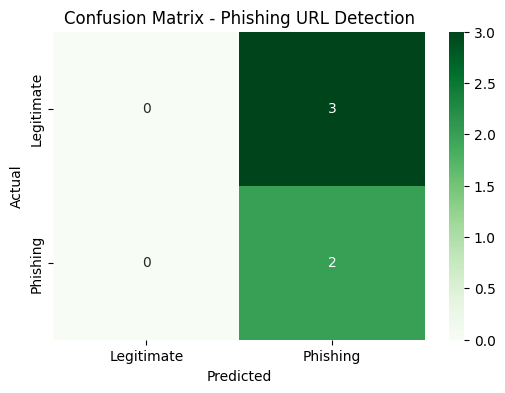


Model saved as: phishing_url_model.pkl
Vectorizer saved as: phishing_vectorizer.pkl

URL Prediction Results:
https://secure-login-paypal-alert.info --> Phishing
https://www.amazon.in/gp/cart/view.html --> Legitimate
http://update-facebook-verification.com --> Phishing
https://accounts.google.com --> Phishing


In [1]:
# ============================================================
# Logistic Regression - Phishing URL Detection
# ============================================================

# Step 1: Import Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
import seaborn as sns
import matplotlib.pyplot as plt
import joblib


# ============================================================
# Step 2: Create Synthetic Dataset
# ============================================================

data = {
    "url": [
        # Legitimate URLs
        "https://www.google.com",
        "https://www.amazon.com/login",
        "https://github.com/openai",
        "https://www.microsoft.com/en-us/",
        "https://www.paypal.com/home",
        "https://www.bankofamerica.com/security",
        "https://www.linkedin.com/in/johndoe",
        "https://www.apple.com/store",

        # Phishing URLs
        "http://paypal-login-security-alert.com",
        "http://verify-account-amazon.biz/login",
        "https://secure-facebook-login-update.ru",
        "http://bankofamerica-login-confirm.net",
        "https://google-account-reset-now.xyz",
        "http://microsoft-support-verification.top",
        "http://appleid-reset-alert.org",
        "https://login-update-github.io"
    ],

    "label": [
        0, 0, 0, 0, 0, 0, 0, 0,
        1, 1, 1, 1, 1, 1, 1, 1
    ]
    # 0 = Legitimate
    # 1 = Phishing
}

df = pd.DataFrame(data)

print("Synthetic phishing URL dataset created.\n")
print(df)


# ============================================================
# Step 3: Data Preprocessing
# ============================================================

X = df["url"]
y = df["label"]

# Convert URLs into numerical features using TF-IDF
# Character-level n-grams are useful for detecting URL patterns
vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5)
)

X_vectorized = vectorizer.fit_transform(X)

print("\nTF-IDF feature extraction completed.")


# ============================================================
# Step 4: Split Dataset
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("\nDataset split completed.")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


# ============================================================
# Step 5: Train Logistic Regression Model
# ============================================================

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

print("\nLogistic Regression model trained successfully.")


# ============================================================
# Step 6: Model Evaluation
# ============================================================

y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy: {:.2f}%".format(accuracy * 100))


# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Legitimate", "Phishing"],
        zero_division=0
    )
)


# ============================================================
# Step 7: Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Legitimate", "Phishing"],
    yticklabels=["Legitimate", "Phishing"]
)

plt.title("Confusion Matrix - Phishing URL Detection")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ============================================================
# Step 8: Save Model and Vectorizer
# ============================================================

joblib.dump(model, "phishing_url_model.pkl")
joblib.dump(vectorizer, "phishing_vectorizer.pkl")

print("\nModel saved as: phishing_url_model.pkl")
print("Vectorizer saved as: phishing_vectorizer.pkl")


# ============================================================
# Step 9: Test New URLs
# ============================================================

new_urls = [
    "https://secure-login-paypal-alert.info",
    "https://www.amazon.in/gp/cart/view.html",
    "http://update-facebook-verification.com",
    "https://accounts.google.com"
]

# Convert new URLs into TF-IDF features
new_features = vectorizer.transform(new_urls)

# Predict
predictions = model.predict(new_features)

print("\nURL Prediction Results:")

for url, prediction in zip(new_urls, predictions):

    if prediction == 1:
        status = "Phishing"
    else:
        status = "Legitimate"

    print(f"{url} --> {status}")